# Case Study: Ứng dụng Deep Learning trong Dự đoán Số lượng Lỗi Phần mềm





Cell 1: Khai báo thư viện và Cấu hình môi trường

In [26]:
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kendalltau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

sns.set_theme(style='whitegrid', palette='muted')
print("Thư viện đã sẵn sàng!")

Thư viện đã sẵn sàng!


Cell 2: Tải dữ liệu và Phân tích tương quan (Correlation)

In [27]:
# === CELL 2: Đọc dữ liệu ===
df = pd.read_csv('dataset.csv')
print(f'Kích thước ban đầu: {df.shape}')
print(f'Số bản ghi trùng lặp: {df.duplicated().sum()}')
print(f'Non-faulty: {(df["bug"]==0).sum()} ({(df["bug"]==0).mean()*100:.1f}%)')
print(f'Faulty:     {(df["bug"]>0).sum()} ({(df["bug"]>0).mean()*100:.1f}%)')
df.head(3)

Kích thước ban đầu: (5258, 22)
Số bản ghi trùng lặp: 743
Non-faulty: 3908 (74.3%)
Faulty:     1350 (25.7%)


,name,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,...,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug
0,org.apache.tools.ant.taskdefs.ExecuteOn,11,4,2,14,42,29,2,12,5,...,1.0,1,0.885057,0.232323,3,4,34.545455,3,1.2727,0
1,org.apache.tools.ant.DefaultLogger,14,1,1,8,32,49,4,4,12,...,1.0,0,0.000000,0.307692,0,0,16.857143,6,1.6429,2
2,org.apache.tools.ant.taskdefs.TaskOutputStream,3,2,0,1,9,0,0,1,1,...,1.0,1,0.714286,0.666667,1,1,17.333333,1,0.6667,0


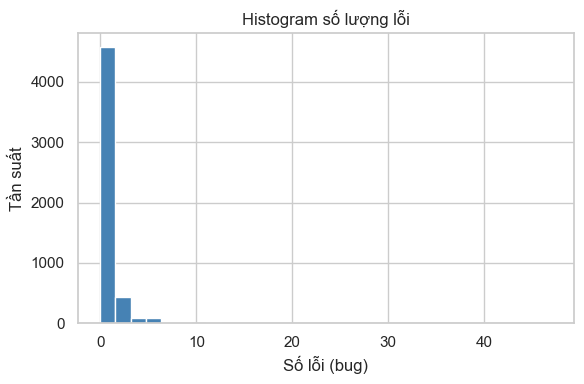

In [35]:
# === CELL 3: Phân phối biến mục tiêu ban đầu (Histogram) ===
plt.figure(figsize=(6, 4))
df_work = df.copy()
plt.hist(df_work['bug'], bins=30, color='steelblue', edgecolor='white')
plt.title('Histogram số lượng lỗi')
plt.xlabel('Số lỗi (bug)')
plt.ylabel('Tần suất')
plt.tight_layout(); plt.show()

Cell 3: Tiền xử lý dữ liệu (Pre-processing)

Các cặp tương quan mạnh |r|>=0.7:


,Feature1,Feature2,r
0,wmc,rfc,0.871
1,wmc,lcom,0.783
2,wmc,npm,0.945
3,wmc,loc,0.706
4,dit,mfa,0.840
5,cbo,ca,0.965
6,rfc,ce,0.712
7,rfc,npm,0.763
8,rfc,loc,0.786
9,lcom,npm,0.780


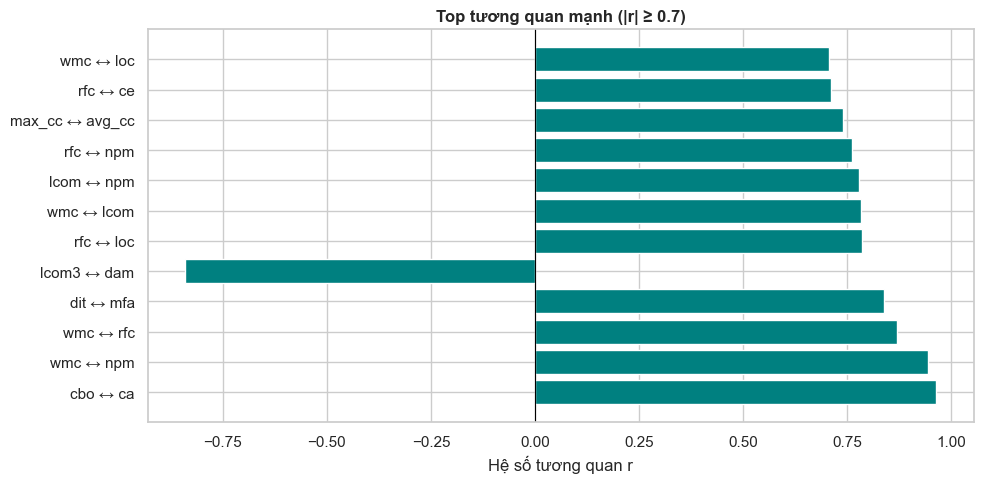

Train: (3160, 20) Test: (1355, 20)


In [29]:
# Tiền xử lý + tương quan + chuẩn hóa
df_work = df_work.drop_duplicates()
drop_cols = [c for c in ['name', 'version', 'class'] if c in df_work.columns]
if drop_cols:
    df_work = df_work.drop(columns=drop_cols)

FEATURE_COLS = [c for c in df_work.columns if c != 'bug']
if len(FEATURE_COLS) < 20:
    raise ValueError(f'Dataset chỉ có {len(FEATURE_COLS)} features, cần tối thiểu 20 theo bài báo.')
FEATURE_COLS = FEATURE_COLS[:20]  # dùng 20 metrics theo bài báo

X = df_work[FEATURE_COLS].values.astype(np.float32)
y = df_work['bug'].values.astype(np.float32)

# Log-transform mục tiêu để giảm lệch
y_log = np.log1p(y)

# Chia train/test 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.30, random_state=42)

# Chuẩn hóa (fit trên train để tránh leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Ma trận tương quan để kiểm tra đa cộng tuyến
corr = df_work[FEATURE_COLS + ['bug']].corr()
strong_pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        v = corr.iloc[i, j]
        if abs(v) >= 0.7:
            strong_pairs.append({'Feature1': cols[i], 'Feature2': cols[j], 'r': round(v, 3)})
print('Các cặp tương quan mạnh |r|>=0.7:')
sp_df = pd.DataFrame(strong_pairs)
display(sp_df)

# Biểu đồ các cặp tương quan mạnh (top 15 theo |r|)
if not sp_df.empty:
    sp_df = sp_df.assign(abs_r=sp_df['r'].abs()).sort_values('abs_r', ascending=False).head(15)
    plt.figure(figsize=(10, 5))
    labels = sp_df['Feature1'] + ' ↔ ' + sp_df['Feature2']
    plt.barh(labels, sp_df['r'], color='teal')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Top tương quan mạnh (|r| ≥ 0.7)', fontweight='bold')
    plt.xlabel('Hệ số tương quan r')
    plt.tight_layout(); plt.show()

print('Train:', X_train_sc.shape, 'Test:', X_test_sc.shape)

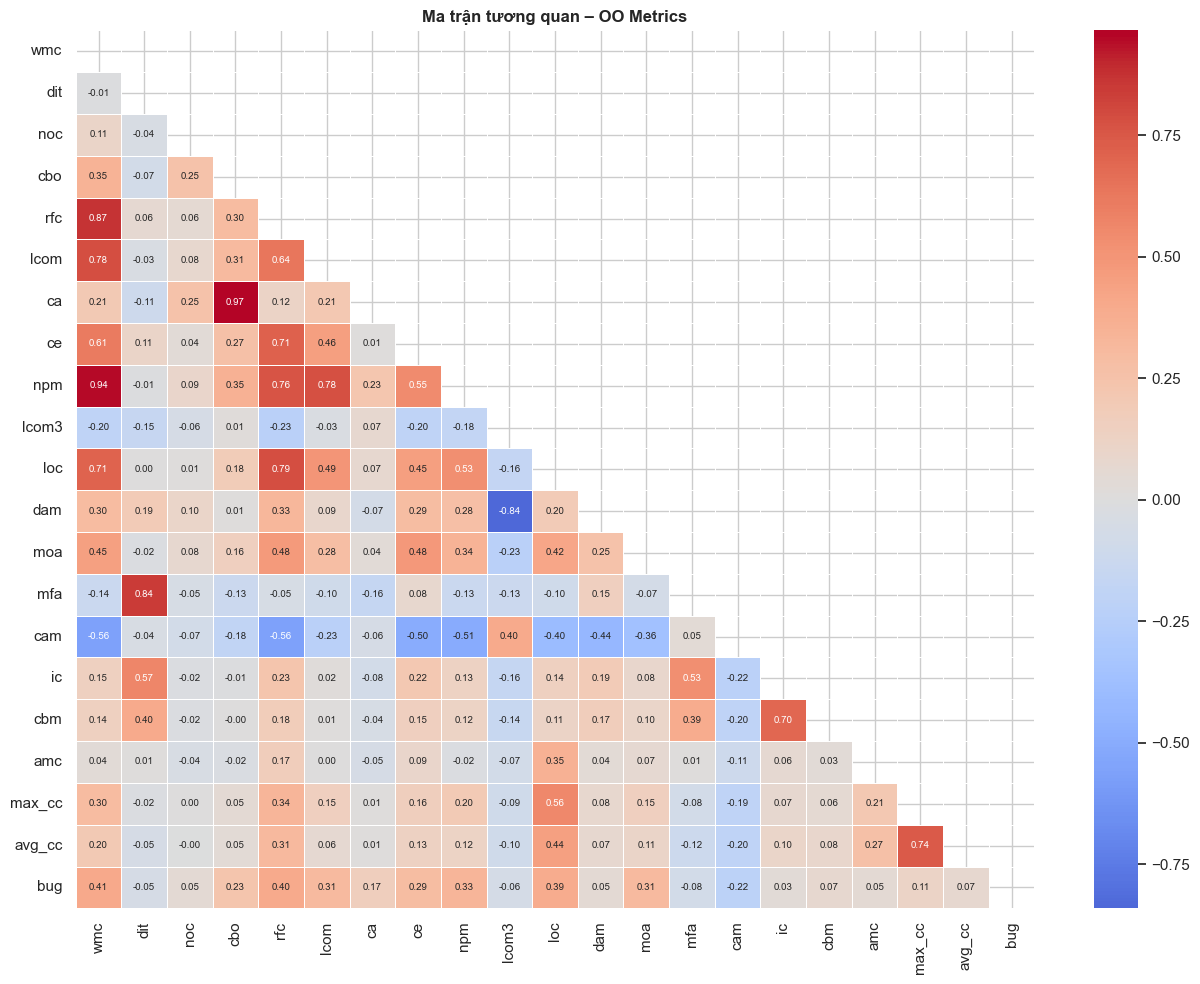

In [30]:
# === CELL 4: Heatmap tương quan ===
plt.figure(figsize=(13, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Ma trận tương quan – OO Metrics', fontweight='bold')
plt.tight_layout(); plt.show()

Cell 4: Xây dựng mạng MLP Đa nhánh (Multi-branch)

In [31]:
# SMOTE + kiến trúc CNN/MLP ()
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    raise ImportError('Chưa có imbalanced-learn. Hãy cài đặt rồi chạy lại cell này.') from e

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
#DT
GROUPS = [
    [0,1,2,3],
    [4,5,6,7],
    [8,9,10,11],
    [12,13,14,15],
    [16,17,18,19],
]
G = 4
#TTNC

def prep_groups(X_arr):
    return [X_arr[:, g] for g in GROUPS]

def discretize(y_arr):
    # Chuyển dữ liệu log về giá trị gốc
    y_orig = np.expm1(y_arr)
    return np.where(y_orig == 0, 0, np.where(y_orig <= 2, 1, 2)) #3

y_train_cls = discretize(y_train)
print('Trước SMOTE:', dict(zip(*np.unique(y_train_cls, return_counts=True))))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_cls_sm = smote.fit_resample(X_train_sc, y_train_cls)
print('Sau SMOTE:', dict(zip(*np.unique(y_cls_sm, return_counts=True))))

group_mean = {0: 0.0, 1: np.log1p(1.5), 2: np.log1p(4.0)}
y_train_sm = np.array([group_mean[c] for c in y_cls_sm], dtype=np.float32)

def build_cnn():
    inputs, outs = [], []
    for _ in range(len(GROUPS)):
        inp = Input(shape=(G, 1))
        x = layers.Conv1D(32, kernel_size=2, activation='relu', kernel_initializer='glorot_uniform')(inp)
        x = layers.MaxPooling1D(pool_size=1)(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Flatten()(x)
        inputs.append(inp); outs.append(x)
    merged = layers.Concatenate()(outs)
    x = layers.Dense(64, activation='relu', kernel_initializer='glorot_uniform')(merged)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='linear')(x)
    m = Model(inputs=inputs, outputs=out)
    m.compile(optimizer='adam', loss='mse')
    return m

def build_mlp():
    inputs, outs = [], []
    for _ in range(len(GROUPS)):
        inp = Input(shape=(G,))
        x = layers.Dense(32, activation='relu', kernel_initializer='glorot_uniform')(inp)
        x = layers.Flatten()(x)
        inputs.append(inp); outs.append(x)
    merged = layers.Concatenate()(outs)
    x = layers.Dense(64, activation='relu', kernel_initializer='glorot_uniform')(merged)
    out = layers.Dense(1, activation='linear')(x)
    m = Model(inputs=inputs, outputs=out)
    m.compile(optimizer='adam', loss='mse')
    return m

print('CNN summary:')
build_cnn().summary()
print('\nMLP summary:')
build_mlp().summary()

Trước SMOTE: {np.int64(0): np.int64(2216), np.int64(1): np.int64(669), np.int64(2): np.int64(275)}
Sau SMOTE: {np.int64(0): np.int64(2216), np.int64(1): np.int64(2216), np.int64(2): np.int64(2216)}
CNN summary:


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_31      │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_32      │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_33      │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_34      │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 3, 32)     │         96 │ input_layer_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 3, 32)     │         96 │ input_layer_31[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 3, 32)     │         96 │ input_layer_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 3, 32)     │         96 │ input_layer_33[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 3, 32)     │         96 │ input_layer_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_15    │ (None, 3, 32)     │          0 │ conv1d_15[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_16    │ (None, 3, 32)     │          0 │ conv1d_16[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_17    │ (None, 3, 32)     │          0 │ conv1d_17[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_18    │ (None, 3, 32)     │          0 │ conv1d_18[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 3, 32)     │          0 │ conv1d_19[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 3, 32)     │          0 │ max_pooling1d_15… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 3, 32)     │          0 │ max_pooling1d_16… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 3, 32)     │          0 │ max_pooling1d_17… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 31,329 (122.38 KB)

 Trainable params: 31,329 (122.38 KB)

...

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_36      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_37      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_38      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_39      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 32)        │        160 │ input_layer_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 32)        │        160 │ input_layer_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 32)        │        160 │ input_layer_37[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │        160 │ input_layer_38[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 32)        │        160 │ input_layer_39[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_35          │ (None, 32)        │          0 │ dense_29[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_36          │ (None, 32)        │          0 │ dense_30[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_37          │ (None, 32)        │          0 │ dense_31[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_38          │ (None, 32)        │          0 │ dense_32[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_39          │ (None, 32)        │          0 │ dense_33[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 160)       │          0 │ flatten_35[0][0], │
│ (Concatenate)       │                   │            │ flatten_36[0][0], │
│                     │                   │            │ flatten_37[0][0], │
│                     │                   │            │ flatten_38[0][0], │
│                     │                   │            │ flatten_39[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 64)        │     10,304 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1)         │         65 │ dense_34[0][0]  

 Total params: 11,169 (43.63 KB)

 Trainable params: 11,169 (43.63 KB)

 Non-trainable params: 0 (0.00 B)

Cell 5: Huấn luyện và Vẽ biểu đồ Loss

In [32]:
# Huấn luyện 2 thực nghiệm (không SMOTE và có SMOTE)
EPOCHS, BATCH, VAL = 100, 16, 0.2
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
results, histories = {}, {}

def run_exp(X_tr, y_tr, X_te, y_te, name):
    X_tr_g = prep_groups(X_tr)
    X_te_g = prep_groups(X_te)

    # CNN
    X_tr_c = [g.reshape(-1, G, 1) for g in X_tr_g]
    X_te_c = [g.reshape(-1, G, 1) for g in X_te_g]
    cnn = build_cnn()
    h_c = cnn.fit(X_tr_c, y_tr, epochs=EPOCHS, batch_size=BATCH,
                  validation_split=VAL, callbacks=[es], verbose=0)
    p_c = cnn.predict(X_te_c, verbose=0).flatten()

    # MLP
    mlp = build_mlp()
    h_m = mlp.fit(X_tr_g, y_tr, epochs=EPOCHS, batch_size=BATCH,
                  validation_split=VAL, callbacks=[es], verbose=0)
    p_m = mlp.predict(X_te_g, verbose=0).flatten()

    results[name] = {
        'CNN': {'MSE': round(mean_squared_error(y_te, p_c), 4),
                'Kendall': round(kendalltau(y_te, p_c).statistic, 4)},
        'MLP': {'MSE': round(mean_squared_error(y_te, p_m), 4),
                'Kendall': round(kendalltau(y_te, p_m).statistic, 4)},
    }
    histories[name] = {'CNN': h_c.history, 'MLP': h_m.history}
    print(f'[{name}] CNN -> MSE={results[name]["CNN"]["MSE"]}, Kendall={results[name]["CNN"]["Kendall"]}')
    print(f'[{name}] MLP -> MSE={results[name]["MLP"]["MSE"]}, Kendall={results[name]["MLP"]["Kendall"]}')

print('Thực nghiệm 1: Không SMOTE')
run_exp(X_train_sc, y_train, X_test_sc, y_test, 'Without SMOTE')
print()
print('Thực nghiệm 2: Có SMOTE')
run_exp(X_train_sm, y_train_sm, X_test_sc, y_test, 'With SMOTE')

Thực nghiệm 1: Không SMOTE
[Without SMOTE] CNN -> MSE=0.2558, Kendall=0.2751
[Without SMOTE] MLP -> MSE=0.2888, Kendall=0.2083

Thực nghiệm 2: Có SMOTE
[With SMOTE] CNN -> MSE=0.3622, Kendall=0.2137
[With SMOTE] MLP -> MSE=0.3337, Kendall=0.2015


Cell 6: Đánh giá kết quả (MSE & Kendall Tau)

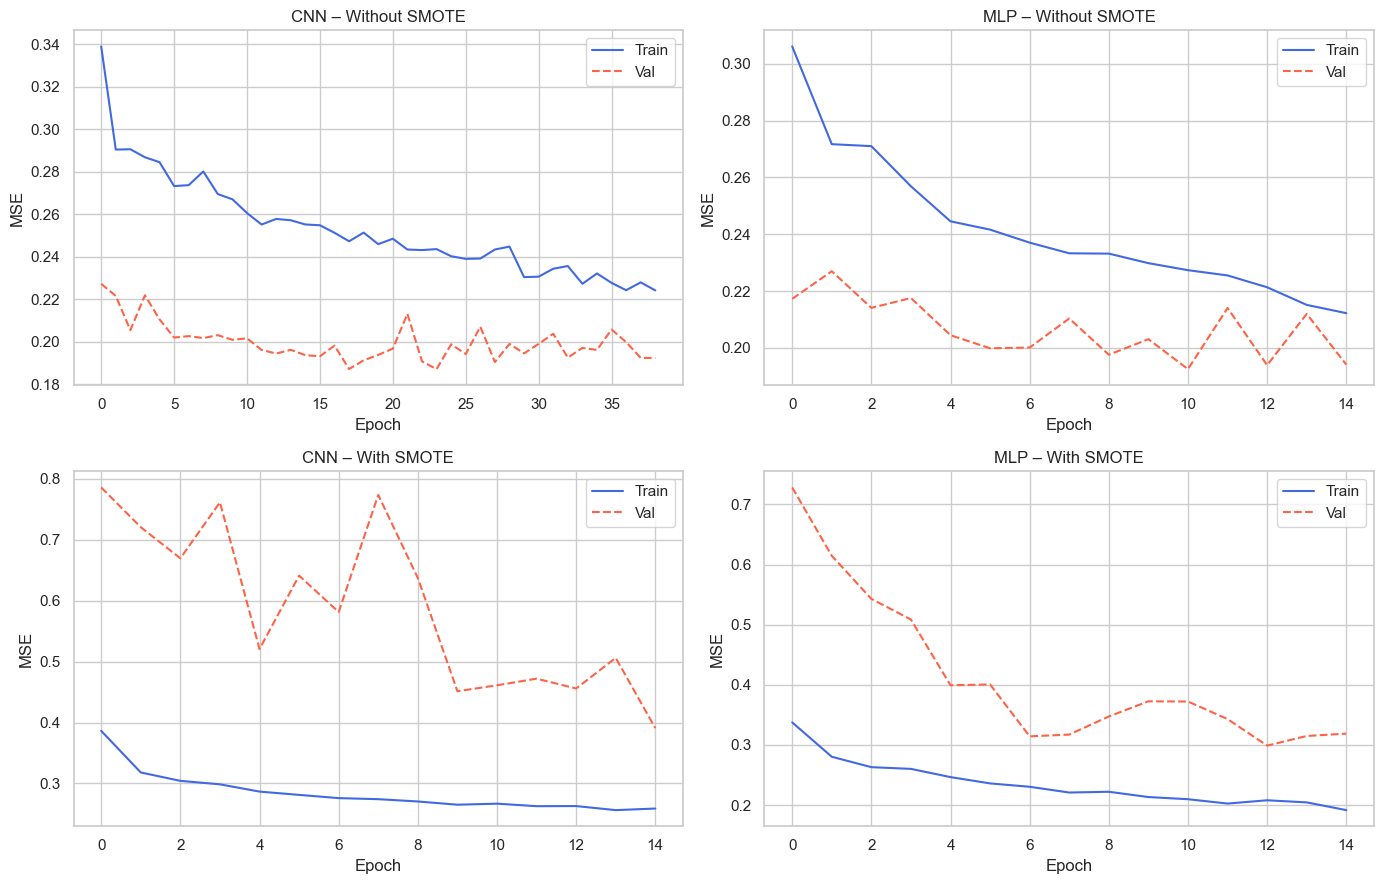

,Thuc nghiem,Mo hinh,MSE,Kendall
0,Without SMOTE,CNN,0.2558,0.2751
1,Without SMOTE,MLP,0.2888,0.2083
2,With SMOTE,CNN,0.3622,0.2137
3,With SMOTE,MLP,0.3337,0.2015


MSE thấp nhất = 0.2558 | CNN | Without SMOTE


In [33]:
# Biểu đồ loss + bảng kết quả tổng hợp
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plots = [('Without SMOTE','CNN',axes[0,0]), ('Without SMOTE','MLP',axes[0,1]),
         ('With SMOTE','CNN',axes[1,0]), ('With SMOTE','MLP',axes[1,1])]
for setting, model, ax in plots:
    h = histories[setting][model]
    ax.plot(h['loss'], label='Train', color='royalblue')
    ax.plot(h['val_loss'], label='Val', color='tomato', ls='--')
    ax.set_title(f'{model} – {setting}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend()
plt.tight_layout(); plt.show()

rows = []
for setting, models in results.items():
    for model, metrics in models.items():
        rows.append({'Thuc nghiem': setting, 'Mo hinh': model,
                     'MSE': metrics['MSE'], 'Kendall': metrics['Kendall']})
df_res = pd.DataFrame(rows)
display(df_res)
min_row = df_res.loc[df_res['MSE'].idxmin()]
print(f"MSE thấp nhất = {min_row['MSE']:.4f} | {min_row['Mo hinh']} | {min_row['Thuc nghiem']}")